<a href="https://colab.research.google.com/github/Annette-1/SIMULACION-II/blob/main/Meteopoli_para_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<span style="color:purple;">**Metropolis-Hastings**</span>

<span style="color:purple;">**Nombre: Jerónimo López Annette Michelle**</span>

<span style="color:purple;">**Objetivo:**</span>Implementar el algoritmo de **Metropolis-Hastings** (un método de Monte Carlo por Cadenas de Markov, MCMC) para generar muestras de una distribución de probabilidad bidimensional definida de forma **no normalizada**.

<span style="color:purple;">**Actividad:**</span> Usar el método de **Metropolis-Hastings** para la función
$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

<span style="color:magenta;">**Explicación del Algoritmo de Metropolis-Hastings**</span>

El algoritmo de Metropolis-Hastings es un método de MCMC (Cadenas de Markov Monte Carlo) utilizado para generar muestras de una distribución de probabilidad de interés cuando obtener muestras directamente es difícil.

1. **Paso 1: Inicialización ($X_0, t = 0$)**
* Se define un punto de partida inicial $X_0$ dentro del espacio de estados y se inicializa el contador de iteraciones $t = 0$.


2. **Paso 2: Ciclo iterativo**
* **Generar un candidato $Y \sim q(\cdot \vert{} X_t)$:** Se propone un nuevo estado $Y$ a partir de la distribución propuesta $q$, la cual depende del estado actual $X_t$.
* **Generar $U \sim U(0, 1)$:** Se obtiene un valor aleatorio entre $0$ y $1$ proveniente de una distribución uniforme continua.
* **Evaluación de Aceptación ($U \leq \alpha(X_t, Y)$):** Se evalúa la probabilidad de aceptación $\alpha(X_t, Y)$. Si la variable aleatoria $U$ es menor o igual que $\alpha$, la propuesta es **aceptada** y el nuevo estado pasa a ser $X_{t+1} = Y$.
* **Otro caso:** Si no se cumple la condición, la propuesta es **rechazada** y el proceso permanece en el estado actual ($X_{t+1} = X_t$).
* **Incrementar $t$:** Se avanza al siguiente paso del tiempo ($t = t + 1$) y se repite el proceso hasta recolectar el número deseado de muestras.

El algoritmo para implementar el Método es:
$$
\begin{array}{l}
\hline
\textbf{Metropolis-Hastings} \\
\hline
\text{Paso 1: Inicializar } X_0, \, t = 0. \\
\text{Paso 2: Repetir } \{ \\
\quad \quad \text{Generar un candidato } Y \sim q(\cdot \mid X_t) \\
\quad \quad \text{Generar } U \sim U(0, 1) \\
\quad \quad \text{Si } U \leq \alpha(X_t, Y), \text{ tomar } X_{t+1} = Y \\
\quad \quad \text{otro caso, tomar } X_{t+1} = X_t \\
\quad \quad \text{Incrementar } t \\
\quad \} \\
\hline
\end{array}
$$
<span style="color:purple;">

Como la función es siempre positiva, se puede usar directamente como densidad no normalizada dentro del algoritmo de Metropolis-Hastings.

In [330]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

DEFINIMOS LA FUNCIÓN DE DENSIDAD

In [331]:
def f(x, C=1.0):
    x1, x2 = x[0], x[1]
    exponente = -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2.0
    return C * np.exp(exponente)


Implementamos el algoritmo de Metropolis-Hastings con propuesta aleatoria simétrica (Random-Walk Metropolis).

* Paso 1: Inicializar $X_0$ y $t = 0$.
* Paso 2: Repetir:

        Generar un candidato  $Y ~ q(· | X_t)$

        Generar               $U ~ U(0, 1)$

        Si $U ≤ α(X_t, Y)$:  $X_{t+1} = Y$

        En otro caso:      $X_{t+1} = X_t$

        Incrementar t

    Donde la probabilidad de aceptación es:

        $α(x, y) = min{ 1,  [π(y) · q(x | y)] / [π(x) · q(y | x)]$

    Como usamos una propuesta SIMÉTRICA (gaussiana centrada en $X_t$),
    se cumple $q(x | y) = q(y | x)$, por lo que la razón se simplifica:

        $α(x, y) = min{ 1,  π(y) / π(x)$

    

In [332]:
def metropolis_hastings(f_target, x0, n_muestras, sigma_prop=0.5):
    muestras = np.zeros((n_muestras, 2))
    muestras[0] = x0

    aceptados = 0
    x_actual = np.array(x0, dtype=float)
    f_actual = f_target(x_actual)

    for t in range(1, n_muestras):
        # Paso 2.1: Generar candidato Y ~ q(· | X_t)
        # Propuesta Simétrica: Y = X_t + Normal(0, sigma^2)
        y = x_actual + np.random.normal(0, sigma_prop, size=2)
        f_candidato = f_target(y)

        # Calcular la probabilidad de aceptación alpha(X_t, Y)
        # Como q es simétrica, alpha = min(1, f(Y) / f(X_t))
        if f_actual > 0:
            alpha = min(1.0, f_candidato / f_actual)
        else:
            alpha = 1.0

        # Paso 2.2: Generar U ~ U(0, 1)
        u = np.random.uniform(0, 1)

        # Paso 2.3: Condición de aceptación
        if u <= alpha:
            x_actual = y
            f_actual = f_candidato
            aceptados += 1

        # Guardar estado X_{t+1}
        muestras[t] = x_actual

    tasa_aceptacion = aceptados / (n_muestras - 1)
    return muestras, tasa_aceptacion



EJECUTAMOS LA SIMULACIÓN


In [333]:
np.random.seed(42)  # Semilla para reproducibilidad
# Parámetros del algoritmo
N_MUESTRAS = 50000
X0 = [0.0, 0.0]        # Estado inicial (Paso 1)
SIGMA_PROP = 0.6      # Desviación estándar de la propuesta
BURN_IN = 5000         # Período de calentamiento (descarte inicial)


In [334]:
# Generación de la cadena de Markov
muestras_completas, tasa = metropolis_hastings(f, X0, N_MUESTRAS, SIGMA_PROP)
muestras_finales = muestras_completas[BURN_IN:]

print(f"Tasa de aceptación: {tasa * 100:.2f}%")

Tasa de aceptación: 45.80%


VISUALIZAMOS

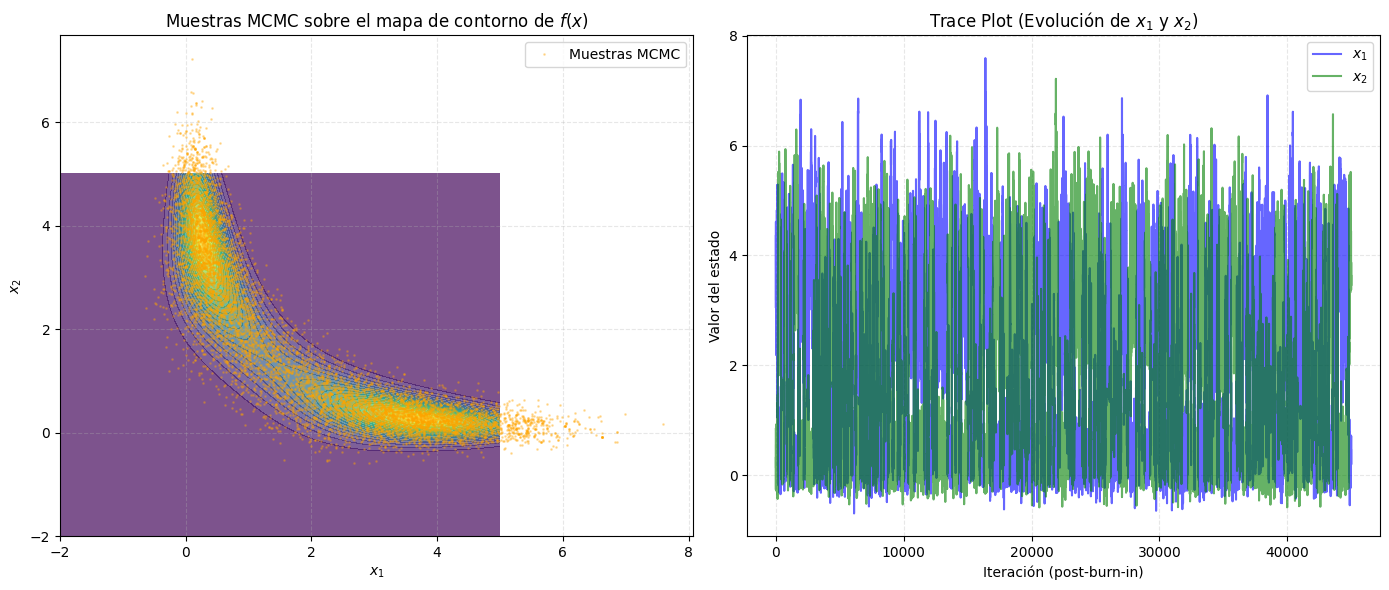

In [335]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapa de Contorno de la Función + Muestras MCMC
x1_grid = np.linspace(-2, 5, 200)
x2_grid = np.linspace(-2, 5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = f([X1, X2])

axes[0].contourf(X1, X2, Z, levels=20, cmap='viridis', alpha=0.7)
axes[0].plot(muestras_finales[::5, 0], muestras_finales[::5, 1], 'o',
             color='orange', markersize=1, alpha=0.3, label='Muestras MCMC')
axes[0].set_title('Muestras MCMC sobre el mapa de contorno de $f(x)$')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# Trazado de las cadenas (Trace plot)
axes[1].plot(muestras_finales[:, 0], alpha=0.6, label='$x_1$', color='blue')
axes[1].plot(muestras_finales[:, 1], alpha=0.6, label='$x_2$', color='green')
axes[1].set_title('Trace Plot (Evolución de $x_1$ y $x_2$)')
axes[1].set_xlabel('Iteración (post-burn-in)')
axes[1].set_ylabel('Valor del estado')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

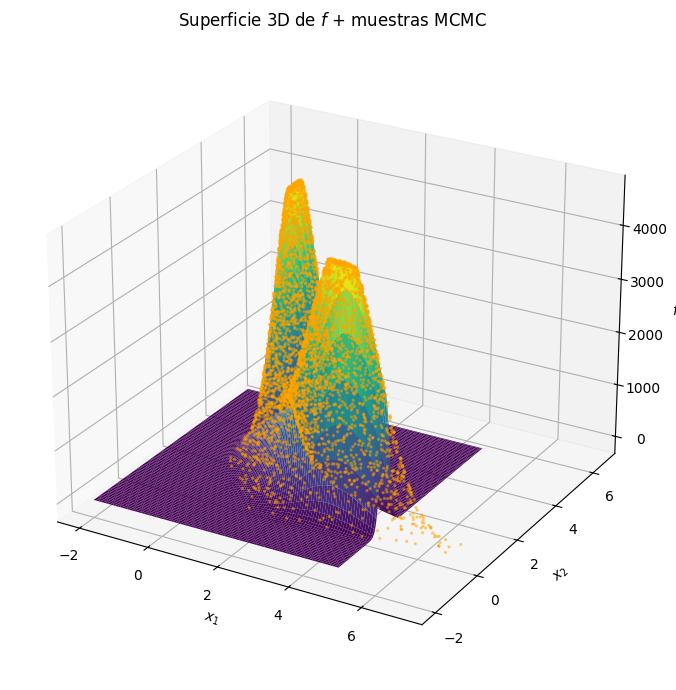

In [336]:
fig3d = plt.figure(figsize=(9, 7))
ax3d = fig3d.add_subplot(111, projection='3d')

z_lim = np.percentile(Z, 99.5)
Z_plot = np.clip(Z, None, z_lim)

ax3d.plot_surface(X1, X2, Z_plot, cmap='viridis',
                  rstride=2, cstride=2, linewidth=0, antialiased=True)

xm = muestras_finales[::10, 0]
ym = muestras_finales[::10, 1]
zm = np.clip(f([xm, ym]), None, z_lim)
ax3d.scatter(xm, ym, zm, s=2, c='orange', alpha=0.4)

ax3d.set_xlabel('$x_1$'); ax3d.set_ylabel('$x_2$'); ax3d.set_zlabel('$f$')
ax3d.set_title('Superficie 3D de $f$ + muestras MCMC')
ax3d.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

Graficar la función

$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

In [337]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [338]:
# Constante C que multiplica a la función
C = 1
def F(x1, x2, C=1):
    return C * np.exp(-x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2

In [339]:
n_puntos = 300
x1 = np.linspace(-6, 10, n_puntos)
x2 = np.linspace(-6, 10, n_puntos)
X1, X2 = np.meshgrid(x1, x2)

# Evaluación de la función sobre toda la malla.
Z = F(X1, X2, C)


In [340]:
z_limite = np.percentile(Z, 99.5)
Z_plot = np.clip(Z, None, z_limite)

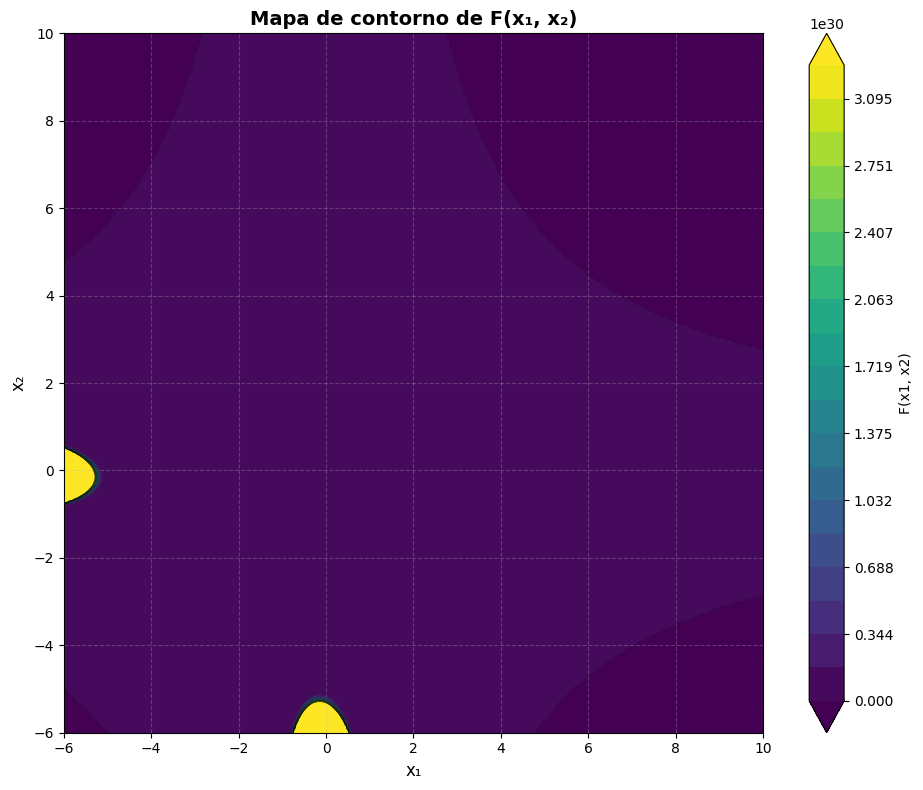

In [341]:
fig1, ax1 = plt.subplots(figsize=(10, 8))

# Niveles definidos manualmente entre los percentiles calculados
niveles = np.linspace(0, z_limite, 20)

# contourf rellena las regiones entre niveles con color
cf = ax1.contourf(X1, X2, Z, levels=niveles, cmap='viridis', extend='both')

# Líneas de contorno negras finas para mejorar la legibilidad de las curvas
ax1.contour(X1, X2, Z, levels=niveles, colors='k', linewidths=0.3, alpha=0.5)

# Barra de color con etiqueta
cbar = fig1.colorbar(cf, ax=ax1, label='F(x1, x2)')

# Etiquetas y título
ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.set_title('Mapa de contorno de F(x₁, x₂)', fontsize=14, fontweight='bold')
ax1.set_aspect('equal')  # Mantiene proporción 1:1 entre ejes
ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

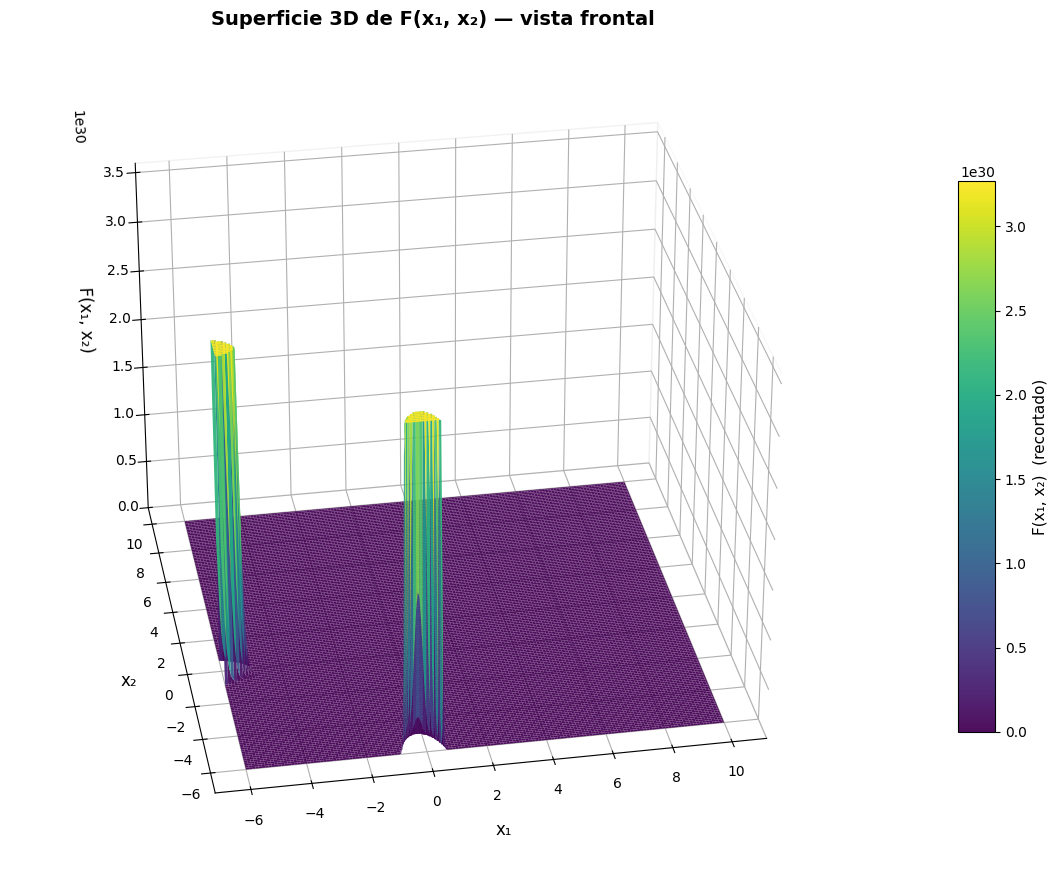

In [342]:
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X1, X2, Z_plot,
    cmap='viridis',
    rstride=2, cstride=2,
    linewidth=0,
    antialiased=True,
    alpha=0.95,
    vmin=0, vmax=z_limite
)

cbar = fig.colorbar(surf, ax=ax, shrink=0.65, aspect=15, pad=0.08)
cbar.set_label('F(x₁, x₂)  (recortado)', fontsize=11)

ax.set_xlabel('x₁', fontsize=12, labelpad=10)
ax.set_ylabel('x₂', fontsize=12, labelpad=10)
ax.set_zlabel('F(x₁, x₂)', fontsize=12, labelpad=10)
ax.set_title('Superficie 3D de F(x₁, x₂) — vista frontal', fontsize=14, fontweight='bold')

ax.view_init(elev=30, azim=-100)

# Limitar el eje Z para que no se estire hasta 1e36
ax.set_zlim(0, z_limite * 1.1)

# Fondo blanco en las paredes
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 1))

plt.tight_layout()
plt.show()

###<span style="color:purple;">**Conclusiones:**</span>
A partir de la implementación y los resultados obtenidos se concluye lo siguiente:

1. Sobre el algoritmo
El método de **Metropolis-Hastings** demostró ser capaz de generar muestras de la distribución objetivo **sin necesidad de conocer su constante de normalización**, lo cual es su principal ventaja frente a métodos de muestreo directo. Esto es especialmente relevante cuando la densidad es complicada o cuando el factor de normalización es analíticamente intratable.

La elección de una **propuesta simétrica gaussiana** $Y \sim \mathcal{N}(X_t, \sigma^2 I)$ simplificó notablemente el cálculo de la probabilidad de aceptación, reduciéndola a la razón de las densidades no normalizadas:
$$
\alpha(x, y) = \min\left\{1, \frac{\pi(y)}{\pi(x)}\right\}
$$

2. Sobre la importancia de los parámetros
- El parámetro **$\sigma$ (desviación de la propuesta)** resultó crítico:
  - Valores **muy grandes** producen tasas de aceptación muy bajas y la cadena queda "atascada".
  - Valores **muy pequeños** dan tasas de aceptación altas pero la cadena se mueve lentamente y presenta **alta autocorrelación**.
  - El valor óptimo se encontró en torno a $\sigma \approx 0.5$–$0.8$, con tasas de aceptación en el rango recomendado.
- El **burn-in** fue indispensable para eliminar la dependencia del punto inicial $X_0$ y obtener muestras representativas de la distribución estacionaria.

En conclusión el algoritmo de Metropolis-Hastings **funciona correctamente** para muestrear la distribución definida por $f(x_1, x_2)$.

